# Create climate dataset for cities in Europe for historical data

In this notebook, we extract climate features from historical data for European cities. We use the ERA5 dataset to obtain monthly averages of climate variables: temperature, precipitation, snowfall, wind speed. We also add temperature related features from hourly data: min, max, range, number of days above 30°C and number of consecutive days above 30°C. The data are aggregated by season on 30-year periods: 1940-1970 and 1994-2024. The final dataset contains climate features for each city and each season.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cfgrib
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

# to resolve xarray FutureWarning
xr.set_options(use_new_combine_kwarg_defaults=True)

In [2]:
# Check all available datasets first
eu_cities = pd.read_csv("datasets/european_cities.csv")
print(eu_cities.shape)
eu_cities.head()

(300, 3)


,name,latitude,longitude
0,Aachen,50.776642,6.08342
1,Aberdeen,57.143688,-2.09814
2,Aix-en-Provence,43.528301,5.44973
3,Alcalá de Henares,40.482052,-3.35996
4,Alicante,38.345169,-0.48149


In [3]:
bern = eu_cities[eu_cities['name'] == 'Bern']
display(bern)

,name,latitude,longitude
26,Bern,46.94809,7.44744


In [4]:
past = "1940-1970"
present = "1994-2024"

period = present

all_datasets = cfgrib.open_datasets(f"era5/{period}.grib")

# Dataset 0 contains: sf, tp
# Dataset 1 contains: t2m, si10
# Each dictionary entry is a cube
ds = {
    'sf': all_datasets[0].sf,
    'tp': all_datasets[0].tp,
    't2m': all_datasets[1].t2m,
    'si10': all_datasets[1].si10
}

for i, dataset in enumerate(all_datasets):
    print(f"Dataset {i}:")
    print(f"  Variables: {list(dataset.data_vars)}")
    print(f"  Dimensions: {dict(dataset.sizes)}")
print("Loaded variables:", list(ds.keys()))
print(f"Dimensions: time={len(all_datasets[0].time)}, lat={len(all_datasets[0].latitude)}, lon={len(all_datasets[0].longitude)}")

Dataset 0:
  Variables: ['sf', 'tp']
  Dimensions: {'time': 372, 'latitude': 149, 'longitude': 281}
Dataset 1:
  Variables: ['t2m', 'si10']
  Dimensions: {'time': 372, 'latitude': 149, 'longitude': 281}
Loaded variables: ['sf', 'tp', 't2m', 'si10']
Dimensions: time=372, lat=149, lon=281


Tha data retrieved from Copernicus are in the form of 4D-hypercubes with dimensions: feature, time, latitude, longitude (4 x 612 x 58 x 58). To visualize it, you can think of a 3D cube linked to each feature (sf, tp, t2m, si10). The 3 dimensions are: time (monthly data from 1970 to 2020), latitude, longitude.

![](images/data_cubes.png)

In [5]:
features = ["sf", "t2m", "tp", "si10"]

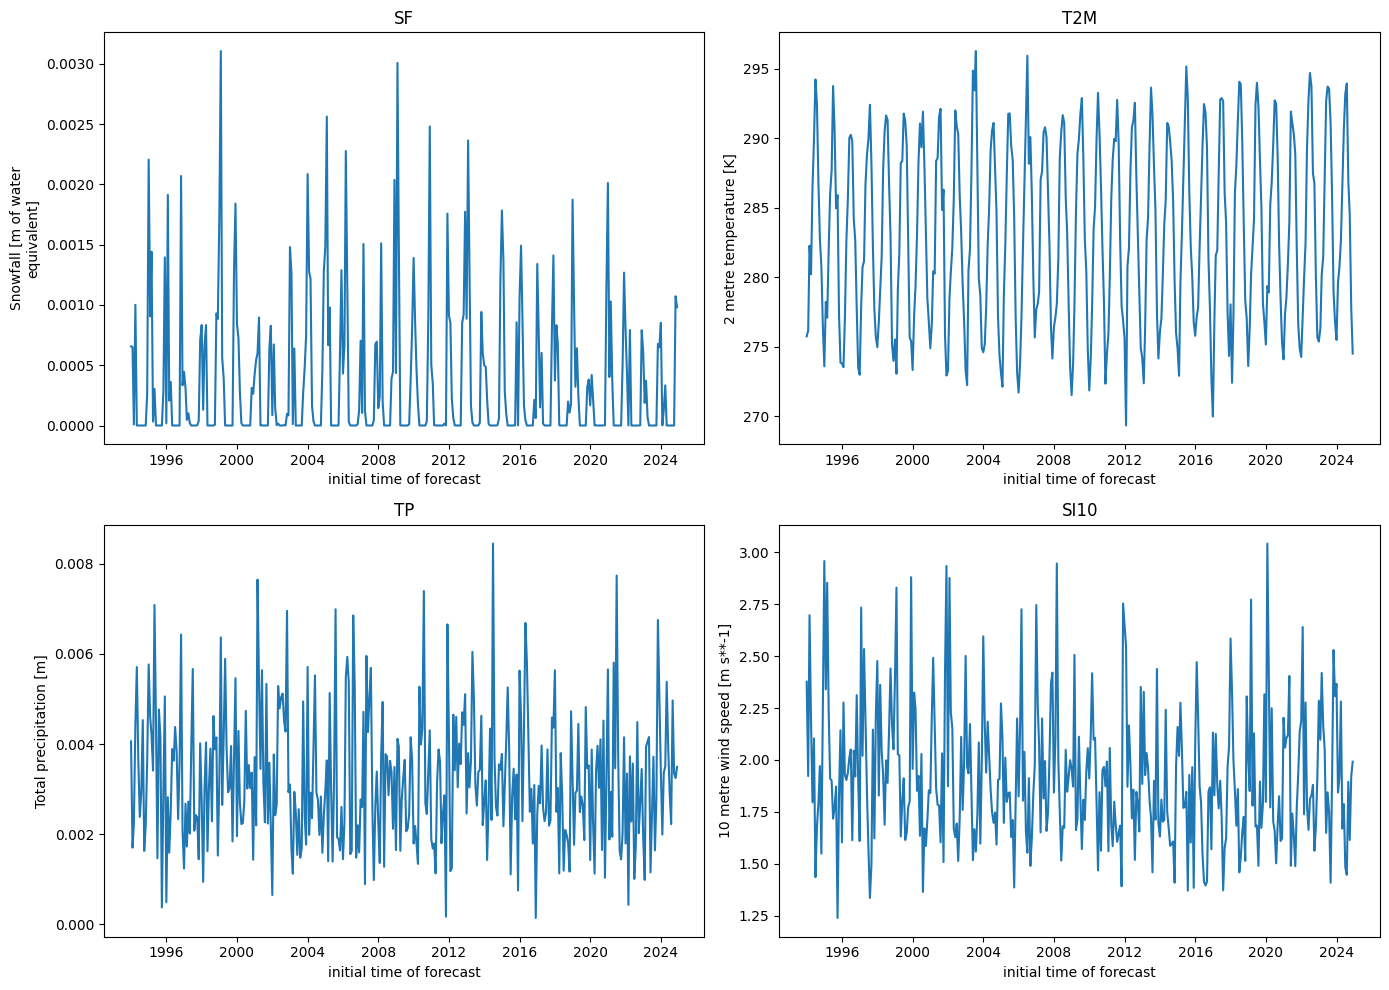

In [6]:
# Plot time series for each feature at Bern's location

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    ds[feat].sel(longitude=bern.longitude.values[0], latitude=bern.latitude.values[0], method='nearest').plot(ax=axes[i])
    axes[i].set_title(f'{feat.upper()}')

plt.tight_layout()
plt.show()

In [7]:
# Example of selecting data for Bern

ds["sf"].sel(longitude=bern.longitude.values[0], latitude=bern.latitude.values[0], method='nearest')

<xarray.DataArray 'sf' (time: 372)> Size: 1kB
[372 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 3kB 1993-12-31T18:00:00 ... 2024-11-30T...
    number      int64 8B 0
    step        timedelta64[ns] 8B 12:00:00
    surface     float64 8B 0.0
    latitude    float64 8B 47.0
    longitude   float64 8B 7.5
    valid_time  (time) datetime64[ns] 3kB ...
Attributes: (12/31)
    GRIB_paramId:                             144
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      41869
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_shortName:                           sf
    GRIB_totalNumber:                         0
    GRIB_units:                               m of water equivalent
    long_name:                                Snowfall
    units:                                    m of water equivalent
    standard_name:                            lwe_thickness_of_snowfall_amount

In [8]:
# Extracrting climate features for all European cities

radius = 0.45

# capitales triées
eu_cap = eu_cities.sort_values(["latitude", "longitude"])

# limites du dataset
lat_min_ds = ds[features[0]].latitude.min().item()
lat_max_ds = ds[features[0]].latitude.max().item()
lon_min_ds = ds[features[0]].longitude.min().item()
lon_max_ds = ds[features[0]].longitude.max().item()

# filtrer les capitales valides
eu_cap = eu_cap[
    (eu_cap['latitude'] >= lat_min_ds) & (eu_cap['latitude'] <= lat_max_ds) &
    (eu_cap['longitude'] >= lon_min_ds) & (eu_cap['longitude'] <= lon_max_ds)
].reset_index(drop=True)

lats = eu_cap["latitude"].values
lons = eu_cap["longitude"].values
names = eu_cap["name"].values

# grille du dataset
lat_ds = ds[features[0]].latitude.values
lon_ds = ds[features[0]].longitude.values

# pré-calcul des indices valides pour chaque capitale
lat_ranges = []
lon_ranges = []

for lat in lats:
    lat_min = lat - radius
    lat_max = lat + radius
    # latitude décroissante
    lat_idx = np.where((lat_ds <= lat_max) & (lat_ds >= lat_min))[0]
    lat_ranges.append(lat_idx)

for lon in lons:
    lon_min = lon - radius
    lon_max = lon + radius
    lon_idx = np.where((lon_ds >= lon_min) & (lon_ds <= lon_max))[0]
    lon_ranges.append(lon_idx)


ds_capitals = {}

for feat in features:
    print(f"Processing feature: {feat}")
    data = ds[feat].values   # (time, 149, 281)
    T, Y, X = data.shape

    out = np.empty((T, len(lats), len(lons)), dtype=np.float32)

    for i in range(len(lats)):
        lat_idx = lat_ranges[i]

        for j in range(len(lons)):
            lon_idx = lon_ranges[j]

            block = data[:, lat_idx[:, None], lon_idx]   # (time, nlat, nlon)

            # moyenne spatiale
            out[:, i, j] = np.nanmean(block, axis=(1, 2))
            if np.isnan(out[:, i, j]).any():
                print(f"Warning: NaN values for feature {feat} at capital index ({i}, {j})")

    ds_capitals[feat] = xr.DataArray(
        out,
        dims=("time", "latitude", "longitude"),
        coords={
            "time": ds[feat].time.values,
            "latitude": lats,
            "longitude": lons
        }
    )


Processing feature: sf
Processing feature: t2m
Processing feature: tp
Processing feature: si10


In [9]:
# Verification
print(f"Original dims: {ds['t2m'].dims}")
print(f"Original shape: {ds['t2m'].shape}")
print(f"Subset dims: {ds_capitals['t2m'].dims}")
print(f"Subset shape: {ds_capitals['t2m'].shape}")

print(f"\nData for first capital ({names[0]}):")
print(f"Latitude: {ds_capitals['t2m'].latitude.values[0]}")
print(f"Longitude: {ds_capitals['t2m'].longitude.values[0]}")
print(f"Mean value: {ds_capitals['t2m'].values[0]}")

Original dims: ('time', 'latitude', 'longitude')
Original shape: (372, 149, 281)
Subset dims: ('time', 'latitude', 'longitude')
Subset shape: (372, 292, 292)

Data for first capital (Marbella):
Latitude: 36.51543
Longitude: -4.88583
Mean value: [[284.30753 284.8961  285.54825 ... 286.99252 288.2416  287.21863]
 [283.46576 284.67084 284.22443 ... 286.95224 288.18768 287.13242]
 [282.40048 284.30722 283.29614 ... 286.87317 288.13257 287.0611 ]
 ...
 [277.7006  277.58032 277.69766 ... 267.4094  277.2229  267.23666]
 [275.14276 274.96918 275.23322 ... 264.83472 269.8443  263.1036 ]
 [274.81357 274.58798 274.8933  ... 264.69714 268.1306  262.51703]]


In [10]:
# We see that we still have 612 time steps for 292 lat/lon = capitals
ds_capitals["t2m"]

<xarray.DataArray (time: 372, latitude: 292, longitude: 292)> Size: 127MB
array([[[284.30753, 284.8961 , 285.54825, ..., 286.99252, 288.2416 ,
         287.21863],
        [283.46576, 284.67084, 284.22443, ..., 286.95224, 288.18768,
         287.13242],
        [282.40048, 284.30722, 283.29614, ..., 286.87317, 288.13257,
         287.0611 ],
        ...,
        [277.7006 , 277.58032, 277.69766, ..., 267.4094 , 277.2229 ,
         267.23666],
        [275.14276, 274.96918, 275.23322, ..., 264.83472, 269.8443 ,
         263.1036 ],
        [274.81357, 274.58798, 274.8933 , ..., 264.69714, 268.1306 ,
         262.51703]],

       [[284.7732 , 285.42715, 285.91464, ..., 285.70993, 288.12085,
         286.16046],
        [284.08325, 285.29626, 284.7379 , ..., 285.6664 , 288.06946,
         286.07202],
        [283.21786, 285.08438, 283.962  , ..., 285.58472, 288.01962,
         285.99704],
...
        [280.64615, 280.56964, 280.70148, ..., 275.23254, 279.7487 ,
         275.32977],
        [278.08554, 277.96396, 278.1434 , ..., 274.55026, 274.31638,
         272.90558],
        [277.64517, 277.45474, 277.70065, ..., 276.52118, 273.15314,
         273.0622 ]],

       [[286.39145, 286.63477, 287.77783, ..., 288.6589 , 290.9956 ,
         288.6639 ],
        [285.5204 , 286.1947 , 286.36792, ..., 288.6307 , 290.9342 ,
         288.5436 ],
        [284.3955 , 285.6227 , 285.37143, ..., 288.55734, 290.87613,
         288.44168],
        ...,
        [279.58105, 279.45328, 279.63705, ..., 271.7394 , 278.45132,
         271.3195 ],
        [276.48108, 276.4005 , 276.53137, ..., 270.39664, 272.25745,
         268.41162],
        [276.063  , 275.91357, 276.14664, ..., 272.08685, 270.3164 ,
         268.41043]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1994-01-01 1994-02-01 ... 2024-12-01
  * latitude   (latitude) float64 2kB 36.52 36.69 36.72 ... 61.5 64.14 65.01
  * longitude  (longitude) float64 2kB -4.886 -6.136 -4.42 ... 23.79 -21.9 25.47

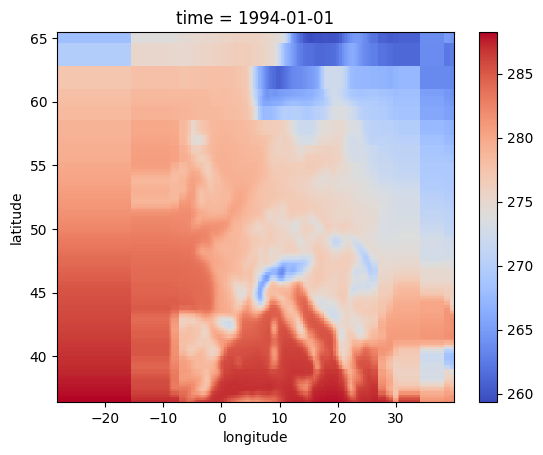

In [11]:
# Plot the temperature data for the first time step across all cities to see if it makes sense

ds_capitals["t2m"][0].sortby(['latitude', 'longitude']).plot(cmap=plt.cm.coolwarm)

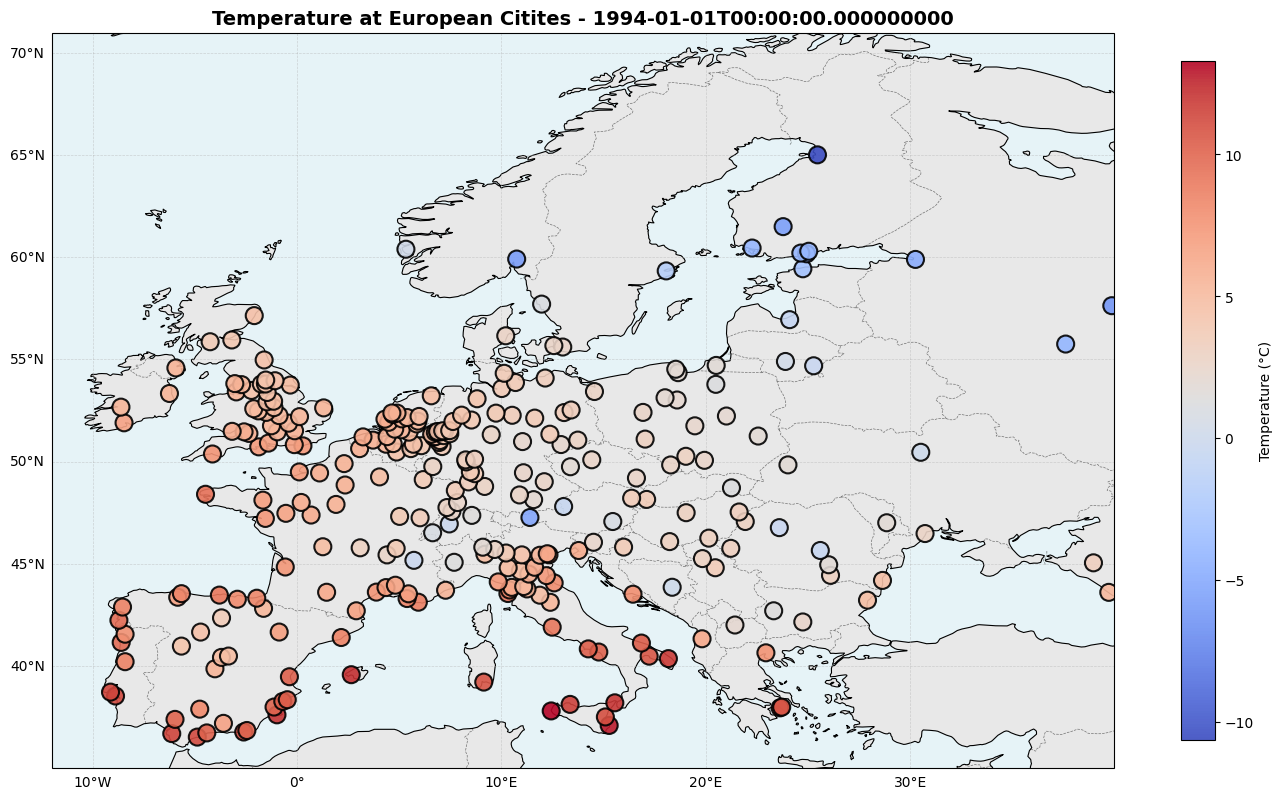

In [12]:
# Enhanced plot with Cartopy for better geographical representation

fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

# Extract the diagonal values (matching lat/lon pairs)
temps = np.diag(ds_capitals["t2m"][0].values) - 273.15  # Convert Kelvin to Celsius
lats = ds_capitals["t2m"].latitude.values
lons = ds_capitals["t2m"].longitude.values

# Plot scatter with correct transform
scatter = ax.scatter(lons, lats, c=temps, cmap='coolwarm', s=150, 
                        edgecolors='black', linewidths=1.5, 
                        transform=ccrs.PlateCarree(), zorder=5, alpha=0.9)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Temperature (°C)', shrink=0.7, pad=0.05)

# Set extent to focus on Europe (West, East, South, North)
ax.set_extent([-12, 40, 35, 71], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(f'Temperature at European Citites - {ds_capitals["t2m"].time.values[0]}', 
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Average climate features for the entire period

For each feature, for each capital (lat,lon), do the mean on the whole period for each season. For example, for the feature "2m temperature" (t2m), for the capital of France (48.8566, 2.3522), do the mean of all winter data from 1940 to 1979, then do the mean of all spring data from 1940 to 1979, and so on until December. In the end, we will have a dataset with 3 + 4 * 4 = 19 columns: city, latitude, longitude, and for each season (4) the 4 features (sf, tp, t2m, si10).

<img src="images/ds_columns_past_v2.png" style="width:1000px;"  />


In [13]:
# Define season mapping
def get_season(month):
    """Map month number to season name"""
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:  # month in [9, 10, 11]
        return 'autumn'

# Calculate seasonal averages over the entire period (1970-2020)
# List to store data for each capital
capital_data = []

# Iterate over each capital
for idx in range(len(lats)):
    lat = lats[idx]
    lon = lons[idx]
    name = names[idx]
    
    # Dictionary to store this capital's data
    row_data = {
        'city': name,
        'latitude': lat,
        'longitude': lon
    }
    
    # For each feature, calculate seasonal averages
    for feat in features:
        # Select data for this capital for the entire time period
        # Extract diagonal to get the correct lat/lon pair
        data_all = ds_capitals[feat]
        
        # Get the diagonal values for this capital across all time steps
        capital_timeseries = data_all.values[:, idx, idx]
        
        # Get the time index
        time_index = data_all.time.values
        
        # Convert to pandas Series for easier grouping by season
        ts = pd.Series(capital_timeseries, index=pd.DatetimeIndex(time_index))
        
        # Map months to seasons and group by season
        seasons = ts.index.month.map(get_season)
        seasonal_means = ts.groupby(seasons).mean()
        
        # Store each season's mean with column name like 'sf_winter', 'sf_spring', etc.
        season_names = ['winter', 'spring', 'summer', 'autumn']
        
        for season_name in season_names:
            if season_name in seasonal_means.index:
                row_data[f'{feat}_{season_name}'] = seasonal_means[season_name]
            else:
                row_data[f'{feat}_{season_name}'] = np.nan
    
    capital_data.append(row_data)

# Create single DataFrame for the entire period
climate_df = pd.DataFrame(capital_data)
print(f"Shape: {climate_df.shape}")
print(f"Columns: {climate_df.columns.tolist()}")
print(f"\nFirst few rows:")
climate_df.head()

Shape: (292, 19)
Columns: ['city', 'latitude', 'longitude', 'sf_winter', 'sf_spring', 'sf_summer', 'sf_autumn', 't2m_winter', 't2m_spring', 't2m_summer', 't2m_autumn', 'tp_winter', 'tp_spring', 'tp_summer', 'tp_autumn', 'si10_winter', 'si10_spring', 'si10_summer', 'si10_autumn']

First few rows:


,city,latitude,longitude,sf_winter,sf_spring,sf_summer,sf_autumn,t2m_winter,t2m_spring,t2m_summer,t2m_autumn,tp_winter,tp_spring,tp_summer,tp_autumn,si10_winter,si10_spring,si10_summer,si10_autumn
0,Marbella,36.515430,-4.88583,6.521474e-06,0.000000e+00,0.0,0.000001,285.430267,288.724213,296.154816,291.505157,0.002328,0.000978,0.000433,0.002674,4.257223,4.083077,3.513703,3.682920
1,Jerez de la Frontera,36.686451,-6.13606,6.056601e-08,0.000000e+00,0.0,0.000000,285.978119,290.186707,297.591827,292.743378,0.002278,0.001049,0.000387,0.002863,4.131226,4.312877,3.731807,3.834314
2,Málaga,36.720161,-4.42034,1.116038e-05,5.554554e-09,0.0,0.000002,284.556122,288.447021,296.498291,291.104126,0.001915,0.000959,0.000410,0.002228,3.641679,3.410915,2.783616,3.075660
3,Roquetas de Mar,36.764191,-2.61475,4.229110e-05,1.354670e-06,0.0,0.000012,285.268860,288.846466,297.007050,291.866272,0.001106,0.000703,0.000383,0.001196,4.358078,4.516621,3.763426,4.024828
4,Almería,36.838139,-2.45974,9.051958e-05,4.722653e-06,0.0,0.000023,284.225311,288.316833,296.958252,291.139038,0.001126,0.000843,0.000512,0.001216,3.905167,4.050331,3.440301,3.597362


## Add info about max and min temperature

In [14]:
temperature_features = pd.read_csv(f"datasets/climate_features_{period}_temp.csv")

In [15]:
# Merge climate features with calculated temperature features (min, max, range, days above 30°C, consecutive days above 30°C)

final_df = climate_df.merge(temperature_features, on=['city', 'latitude', 'longitude']).sort_values('city').reset_index(drop=True)

In [16]:
# Display info about the dataset
print(f"Dataset shape: {final_df.shape}")
print(f"Number of cities: {len(final_df)}")
print(f"Number of columns: {final_df.shape[1]}")
print(f"\nColumn names: {final_df.columns.tolist()}")
    
# Show first 5 and last 5 rows
print("\n" + "="*50)
print("First 5 cities:")
display(final_df.head())
print("\nLast 5 cities:")
display(final_df.tail())

Dataset shape: (292, 33)
Number of cities: 292
Number of columns: 33

Column names: ['city', 'latitude', 'longitude', 'sf_winter', 'sf_spring', 'sf_summer', 'sf_autumn', 't2m_winter', 't2m_spring', 't2m_summer', 't2m_autumn', 'tp_winter', 'tp_spring', 'tp_summer', 'tp_autumn', 'si10_winter', 'si10_spring', 'si10_summer', 'si10_autumn', 'max_t2m_winter', 'min_t2m_winter', 'temp_range_winter', 'max_t2m_spring', 'min_t2m_spring', 'temp_range_spring', 'max_t2m_summer', 'min_t2m_summer', 'temp_range_summer', 'max_t2m_autumn', 'min_t2m_autumn', 'temp_range_autumn', 'hot_days', 'hot_days_consec']

First 5 cities:


,city,latitude,longitude,sf_winter,sf_spring,sf_summer,sf_autumn,t2m_winter,t2m_spring,t2m_summer,...,min_t2m_spring,temp_range_spring,max_t2m_summer,min_t2m_summer,temp_range_summer,max_t2m_autumn,min_t2m_autumn,temp_range_autumn,hot_days,hot_days_consec
0,Aachen,50.776642,6.08342,0.000442,2.974464e-05,0.0,0.000223,276.150513,282.535431,290.519135,...,278.55936,7.805359,294.68848,286.11887,8.569611,286.72693,280.66290,6.064026,4.516129,2.419355
1,Aberdeen,57.143688,-2.09814,0.000253,3.000838e-05,0.0,0.000076,278.421021,280.556702,286.508911,...,278.68793,3.636139,288.23520,284.64053,3.594666,285.11330,281.82422,3.289093,0.000000,0.000000
2,Aix-en-Provence,43.528301,5.44973,0.000061,7.455921e-07,0.0,0.000022,280.454865,286.838257,296.205750,...,282.45444,8.699921,300.89980,291.24628,9.653534,292.83588,284.87067,7.965210,21.838710,8.064516
3,Alcalá de Henares,40.482052,-3.35996,0.000131,8.180150e-06,0.0,0.000041,279.049835,286.128876,297.464478,...,280.33120,11.424316,304.17325,290.07108,14.102173,293.20895,282.69815,10.510803,68.774194,24.838710
4,Alicante,38.345169,-0.48149,0.000021,4.917917e-07,0.0,0.000014,284.594177,288.988678,297.886963,...,285.46976,7.074585,301.44280,294.33557,7.107239,295.50272,288.98346,6.519257,24.225806,8.580645



Last 5 cities:


,city,latitude,longitude,sf_winter,sf_spring,sf_summer,sf_autumn,t2m_winter,t2m_spring,t2m_summer,...,min_t2m_spring,temp_range_spring,max_t2m_summer,min_t2m_summer,temp_range_summer,max_t2m_autumn,min_t2m_autumn,temp_range_autumn,hot_days,hot_days_consec
287,Zagreb,45.814442,15.977980,0.000588,0.000024,0.00000,0.000310,275.314148,285.029602,294.782776,...,279.92825,10.266693,300.30292,289.38450,10.918427,289.51900,281.05563,8.463379,27.000000,8.000000
288,Zaragoza,41.656059,-0.877340,0.000068,0.000006,0.00000,0.000028,280.500854,287.562317,297.473083,...,281.96800,11.427673,304.40607,290.74237,13.663696,294.23422,283.97080,10.263428,69.193548,18.935484
289,Zürich,47.366669,8.550000,0.001551,0.000357,0.00003,0.001014,273.845184,281.455505,290.405762,...,277.28427,8.508759,294.90600,286.05472,8.851288,285.80658,279.31570,6.490875,3.064516,1.806452
290,Århus,56.156738,10.210760,0.000470,0.000020,0.00000,0.000165,275.487640,280.380768,289.385529,...,277.80273,5.016479,292.04962,286.39926,5.650360,285.14374,281.44608,3.697662,0.000000,0.000000
291,Łódź,51.750000,19.466669,0.000579,0.000047,0.00000,0.000294,272.971649,281.954895,291.844452,...,277.09930,9.185425,296.68204,286.45020,10.231842,286.01324,278.78146,7.231781,7.741935,3.193548


In [17]:
# Check for any missing values
missing_counts = final_df.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("\nMissing values per column:")
    print(missing_counts[missing_counts > 0])

Total missing values: 0


In [18]:
# Save the dataset as a CSV file
final_df.to_csv(f"datasets/climate_features_{period}.csv", index=False)
print(f"Saved climate_features_{period}.csv")

Saved climate_features_1994-2024.csv
